In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

df = pd.read_csv("/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv")

/kaggle/input/napier-cleaned-data/Empty_Land_Cleaned.csv
/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv
/kaggle/input/napier-data/Napier_Data_new_0827.csv


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13854 entries, 0 to 13853
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Number           13854 non-null  int64 
 1   Sale.Date        13854 non-null  object
 2   Full Address     13854 non-null  object
 3   Bathrooms        12789 non-null  object
 4   Age              13854 non-null  object
 5   Total$           13854 non-null  object
 6   Land Area m2     13854 non-null  int64 
 7   Flrm2            13854 non-null  int64 
 8   Land$            13854 non-null  object
 9   Capital$         13854 non-null  object
 10  Brms             13854 non-null  object
 11  Pirimai          13854 non-null  int64 
 12  Onekawa          13854 non-null  int64 
 13  Marewa           13854 non-null  int64 
 14  Hospital Hill    13854 non-null  int64 
 15  Bluff Hill       13854 non-null  int64 
 16  flooding_status  13854 non-null  int64 
 17  flooding_zone    13854 non-null

In [3]:
df.isna().sum()

Number                0
Sale.Date             0
Full Address          0
Bathrooms          1065
Age                   0
Total$                0
Land Area m2          0
Flrm2                 0
Land$                 0
Capital$              0
Brms                  0
Pirimai               0
Onekawa               0
Marewa                0
Hospital Hill         0
Bluff Hill            0
flooding_status       0
flooding_zone         0
dtype: int64

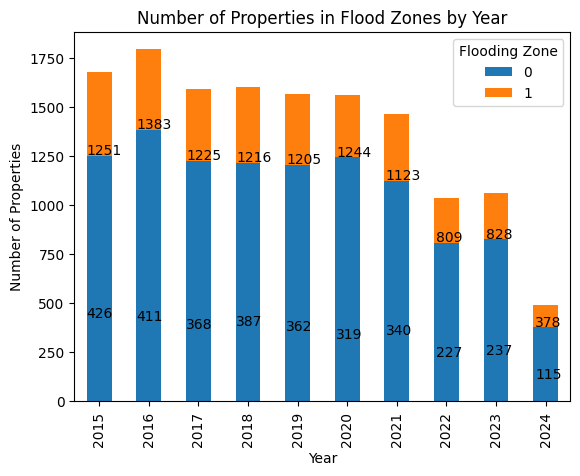

In [4]:
# Libraries
# Convert 'Sale.Date' to datetime format
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')

# Extract the year from 'Sale.Date'
df['Year'] = df['Sale.Date'].dt.year

# Group by 'Year' and 'flooding_zone' and count the occurrences
flood_zone_counts = df.groupby(['Year', 'flooding_zone']).size().unstack(fill_value=0)

# Plotting the data
ax =  flood_zone_counts.plot(kind='bar', stacked=True)
plt.title('Number of Properties in Flood Zones by Year')
plt.xlabel('Year')
plt.ylabel('Number of Properties')
plt.legend(title='Flooding Zone')
# Adding the numbers on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
    
plt.show()

/tmp/ipykernel_17/2037918162.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2018['Month'] = df_2018['Sale.Date'].dt.month


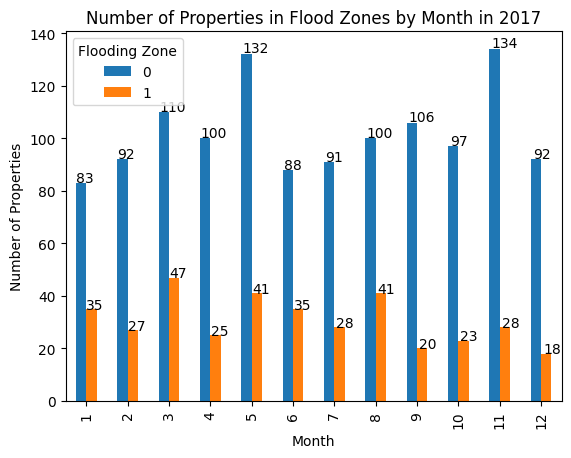

In [5]:
# Convert 'Sale.Date' to datetime format
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')

# Filter the data for the year 2020
df_2018 = df[df['Sale.Date'].dt.year == 2017]

# Extract the month from 'Sale.Date'
df_2018['Month'] = df_2018['Sale.Date'].dt.month

# Group by 'Month' and 'flooding_zone' and count the occurrences for 2020
flood_zone_2018_month_counts = df_2018.groupby(['Month', 'flooding_zone']).size().unstack(fill_value=0)

# Plotting the data with numbers displayed on the bars
ax = flood_zone_2018_month_counts.plot(kind='bar', stacked=False)
plt.title('Number of Properties in Flood Zones by Month in 2017')
plt.xlabel('Month')
plt.ylabel('Number of Properties')
plt.legend(title='Flooding Zone')

# Adding the numbers on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
    
plt.show()

/tmp/ipykernel_17/3352283514.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2018['Month'] = df_2018['Sale.Date'].dt.month


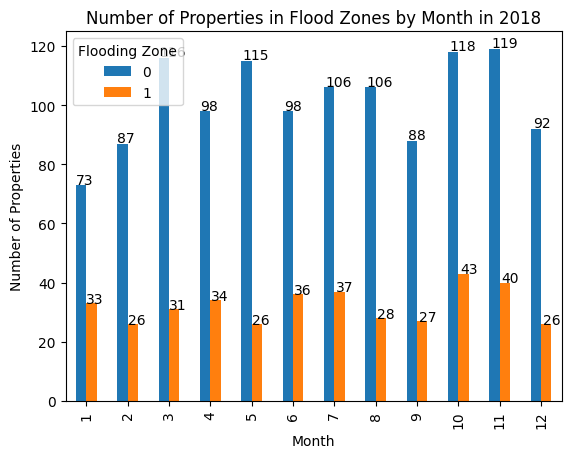

In [6]:
# Convert 'Sale.Date' to datetime format
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')

# Filter the data for the year 2020
df_2018 = df[df['Sale.Date'].dt.year == 2018]

# Extract the month from 'Sale.Date'
df_2018['Month'] = df_2018['Sale.Date'].dt.month

# Group by 'Month' and 'flooding_zone' and count the occurrences for 2020
flood_zone_2018_month_counts = df_2018.groupby(['Month', 'flooding_zone']).size().unstack(fill_value=0)

# Plotting the data with numbers displayed on the bars
ax = flood_zone_2018_month_counts.plot(kind='bar', stacked=False)
plt.title('Number of Properties in Flood Zones by Month in 2018')
plt.xlabel('Month')
plt.ylabel('Number of Properties')
plt.legend(title='Flooding Zone')

# Adding the numbers on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
    
plt.show()

/tmp/ipykernel_17/3310722791.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2019['Month'] = df_2019['Sale.Date'].dt.month


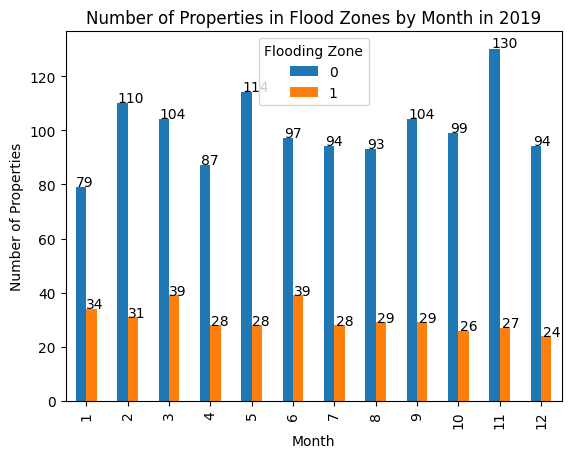

In [7]:
# Convert 'Sale.Date' to datetime format
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')

# Filter the data for the year 2020
df_2019 = df[df['Sale.Date'].dt.year == 2019]

# Extract the month from 'Sale.Date'
df_2019['Month'] = df_2019['Sale.Date'].dt.month

# Group by 'Month' and 'flooding_zone' and count the occurrences for 2020
flood_zone_2019_month_counts = df_2019.groupby(['Month', 'flooding_zone']).size().unstack(fill_value=0)

# Plotting the data with numbers displayed on the bars
ax = flood_zone_2019_month_counts.plot(kind='bar', stacked=False)
plt.title('Number of Properties in Flood Zones by Month in 2019')
plt.xlabel('Month')
plt.ylabel('Number of Properties')
plt.legend(title='Flooding Zone')

# Adding the numbers on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
    
plt.show()

/tmp/ipykernel_17/1207527932.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2020['Month'] = df_2020['Sale.Date'].dt.month


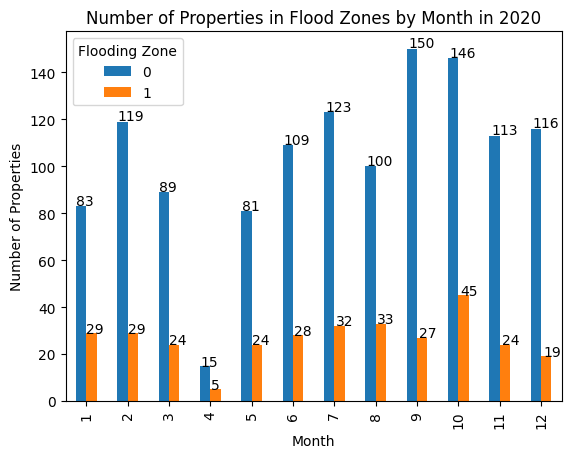

In [8]:
# Convert 'Sale.Date' to datetime format
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')

# Filter the data for the year 2020
df_2020 = df[df['Sale.Date'].dt.year == 2020]

# Extract the month from 'Sale.Date'
df_2020['Month'] = df_2020['Sale.Date'].dt.month

# Group by 'Month' and 'flooding_zone' and count the occurrences for 2020
flood_zone_2020_month_counts = df_2020.groupby(['Month', 'flooding_zone']).size().unstack(fill_value=0)

# Plotting the data with numbers displayed on the bars
ax = flood_zone_2020_month_counts.plot(kind='bar', stacked=False)
plt.title('Number of Properties in Flood Zones by Month in 2020')
plt.xlabel('Month')
plt.ylabel('Number of Properties')
plt.legend(title='Flooding Zone')

# Adding the numbers on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
    
plt.show()

/tmp/ipykernel_17/1260020719.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2020['Month'] = df_2020['Sale.Date'].dt.month


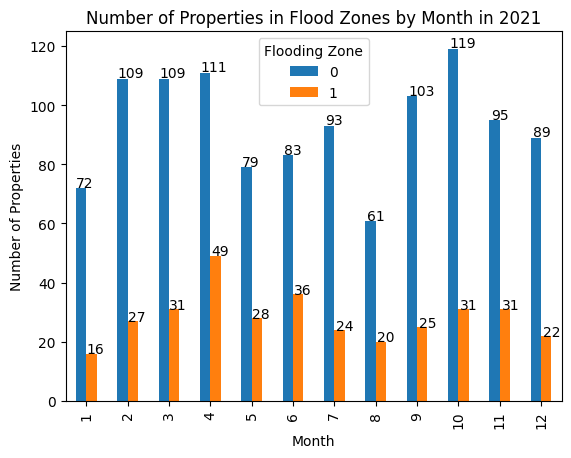

In [9]:
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')

# Filter the data for the year 2020
df_2020 = df[df['Sale.Date'].dt.year == 2021]

# Extract the month from 'Sale.Date'
df_2020['Month'] = df_2020['Sale.Date'].dt.month

# Group by 'Month' and 'flooding_zone' and count the occurrences for 2020
flood_zone_2020_month_counts = df_2020.groupby(['Month', 'flooding_zone']).size().unstack(fill_value=0)

# Plotting the data
ax = flood_zone_2020_month_counts.plot(kind='bar', stacked=False)
plt.title('Number of Properties in Flood Zones by Month in 2021')
plt.xlabel('Month')
plt.ylabel('Number of Properties')
plt.legend(title='Flooding Zone')

# Adding the numbers on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
    
plt.show()

/tmp/ipykernel_17/1961282190.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2020['Month'] = df_2020['Sale.Date'].dt.month


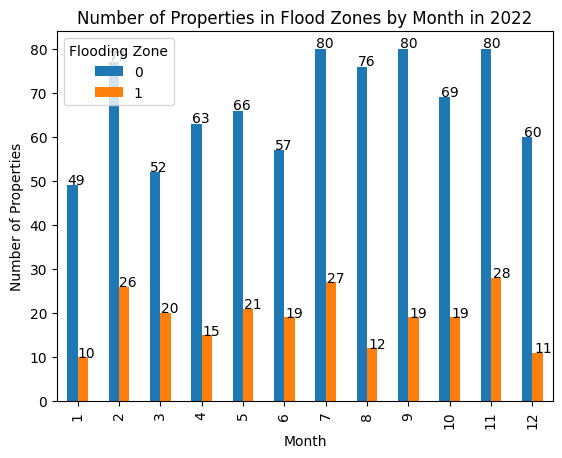

In [10]:
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')

# Filter the data for the year 2020
df_2020 = df[df['Sale.Date'].dt.year == 2022]

# Extract the month from 'Sale.Date'
df_2020['Month'] = df_2020['Sale.Date'].dt.month

# Group by 'Month' and 'flooding_zone' and count the occurrences for 2020
flood_zone_2020_month_counts = df_2020.groupby(['Month', 'flooding_zone']).size().unstack(fill_value=0)

# Plotting the data
ax = flood_zone_2020_month_counts.plot(kind='bar', stacked=False)
plt.title('Number of Properties in Flood Zones by Month in 2022')
plt.xlabel('Month')
plt.ylabel('Number of Properties')
plt.legend(title='Flooding Zone')
# Adding the numbers on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
plt.show()

In [11]:
import pandas as pd
import statsmodels.api as sm

# Load the dataset
file_path = '/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv'
df = pd.read_csv(file_path)

# Convert currency columns to numeric after removing any non-numeric characters
df['Total$'] = df['Total$'].replace('[\$,]', '', regex=True).astype(float)

# Convert other columns to numeric where appropriate
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


# Convert 'Sale.Date' to datetime and extract the 'Year'
df['Sale.Date'] = pd.to_datetime(df['Sale.Date'], format='%d/%m/%Y', errors='coerce')
df['Year'] = df['Sale.Date'].dt.year

# Ensure all numeric columns are actually numeric
numeric_cols = ['Year', 'Age', 'Bathrooms','Brms', 'Pirimai', 'Onekawa', 'Marewa', 'Hospital Hill', 'Bluff Hill', 
                'flooding_status', 'flooding_zone', 'Total$']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any remaining rows with NaN values in the features or target
df = df.dropna(subset=numeric_cols)

# Select the features and the target variable
features = ['Year', 'Age', 'Bathrooms', 'Brms', 'Pirimai', 'Onekawa', 'Marewa', 'Hospital Hill', 'Bluff Hill', 
            'flooding_status', 'flooding_zone']
X = df[features]
y = df['Total$']

# Add a constant to the model (intercept term)
X = sm.add_constant(X)

# Check the data types to ensure all are numeric
print(X.dtypes)
print(y.dtypes)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the summary of the model
model_summary = model.summary()
model_summary

const              float64
Year                 int32
Age                float64
Bathrooms          float64
Brms               float64
Pirimai              int64
Onekawa              int64
Marewa               int64
Hospital Hill        int64
Bluff Hill           int64
flooding_status      int64
flooding_zone        int64
dtype: object
float64


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Total$   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     1108.
Date:                Mon, 16 Sep 2024   Prob (F-statistic):               0.00
Time:                        09:09:15   Log-Likelihood:            -1.6887e+05
No. Observations:               12361   AIC:                         3.378e+05
Df Residuals:                   12349   BIC:                         3.379e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.201e+08   1.62e+06    -74.027      0.000   -1.23e+08   -1.17e+08
Year             5.948e+04    803.838     73.997      0.000    5.79e+04    6.11e+04
Age               172.8318      3.823     45.214      0.000     165.339     180.324
Bathrooms        1.007e+05   3049.837     33.022      0.000    9.47e+04    1.07e+05
Brms             4.313e+04   1713.438     25.170      0.000    3.98e+04    4.65e+04
Pirimai         -3903.7400   1.89e+04     -0.207      0.836   -4.09e+04    3.31e+04
Onekawa         -3.537e+04   1.48e+04     -2.386      0.017   -6.44e+04   -6315.912
Marewa          -3.416e+04   1.57e+04     -2.181      0.029   -6.49e+04   -3456.766
Hospital Hill      9.2e+04   1.91e+04      4.820      0.000    5.46e+04    1.29e+05
Bluff Hill       1.044e+05    1.8e+04      5.792      0.000     6.9e+04     1.4e+05
flooding_status  1.613e+04   6524.085      2.473      0.013    3342.664    2.89e+04
flooding_zone   -8.612e+04    1.7e+04     -5.081      0.000   -1.19e+05   -5.29e+04
==============================================================================
Omnibus:                     7554.569   Durbin-Watson:                   1.763
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           213094.308
Skew:                           2.451   Prob(JB):                         0.00
Kurtosis:                      22.741   Cond. No.                     2.39e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.39e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load the dataset
#file_path = '/kaggle/input/napier-data/Napier_Data_new_0827.csv'
file_path = '/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv'
data = pd.read_csv(file_path)

# Convert 'Total$' to numeric and handle non-numeric characters
data['Total$'] = pd.to_numeric(data['Total$'].replace('[\$,]', '', regex=True), errors='coerce')

# Create 'Ln_Total' by taking the logarithm of 'Total$'
data['Ln_Total'] = np.log(data['Total$'])

# Drop rows with missing values in the relevant columns
data_clean = data.dropna(subset=['Ln_Total', 'Flrm2', 'Bathrooms', 'Brms','Age'])

# Verify the cleaned data
print(data_clean[['Ln_Total', 'Flrm2', 'Bathrooms','Brms', 'Age']].head())

# Define the Difference-in-Differences (DiD) model formula
did_formula = 'Ln_Total ~ flooding_status + flooding_zone + Flrm2 +  Bathrooms + Brms + Age'

# Fit the DiD model using OLS regression
did_model = smf.ols(formula=did_formula, data=data_clean).fit()

# Display the model summary
print(did_model.summary())


    Ln_Total  Flrm2 Bathrooms Brms   Age
0  13.304685    170         1    3  1990
1  14.603968    220         2    3  1990
2  13.134292     90         1    3  1950
4  13.795308    200         2    3  2000
5  13.437174    180         1    3  1970
                            OLS Regression Results                            
Dep. Variable:               Ln_Total   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     301.6
Date:                Mon, 16 Sep 2024   Prob (F-statistic):               0.00
Time:                        09:09:15   Log-Likelihood:                -5038.1
No. Observations:               12789   AIC:                         1.016e+04
Df Residuals:                   12747   BIC:                         1.047e+04
Df Model:                          41                                         
Covariance Type:            nonrobust      

/tmp/ipykernel_17/1167701995.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['Sale.Date'] = pd.to_datetime(data_clean['Sale.Date'], dayfirst=True, errors='coerce')


                            OLS Regression Results                            
Dep. Variable:               Ln_Total   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     1976.
Date:                Mon, 16 Sep 2024   Prob (F-statistic):               0.00
Time:                        09:09:16   Log-Likelihood:                -4761.2
No. Observations:               12361   AIC:                             9536.
Df Residuals:                   12354   BIC:                             9588.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          12.3225      0.018    6

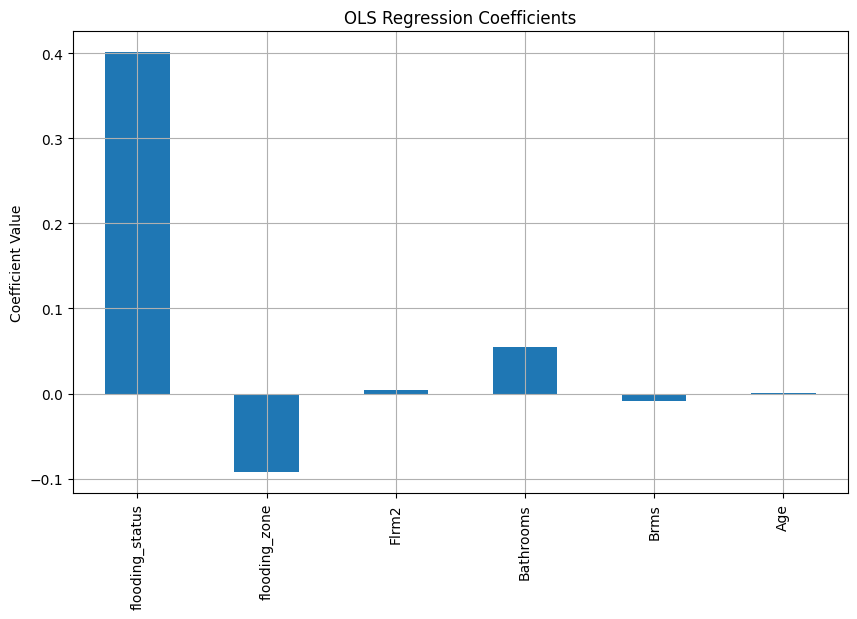

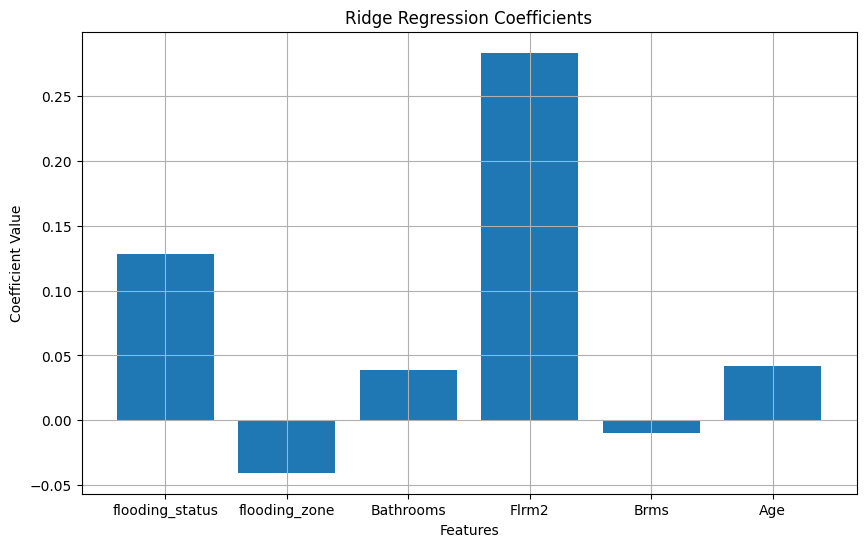

In [13]:

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 数据加载和预处理
# 确保 'Total$' 是数值型并处理非数值字符
file_path = '/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv'
data = pd.read_csv(file_path)
data['Total$'] = pd.to_numeric(data['Total$'].replace('[\$,]', '', regex=True), errors='coerce')

# 计算 'Ln_Total'
data['Ln_Total'] = np.log(data['Total$'])

# 删除缺失值
data_clean = data.dropna(subset=['Ln_Total', 'Flrm2', 'Bathrooms', 'Brms', 'Age'])

# 2. 使用最近十年数据进行分析
# 过滤出过去十年的数据并使用 dayfirst=True 处理日期
data_clean['Sale.Date'] = pd.to_datetime(data_clean['Sale.Date'], dayfirst=True, errors='coerce')

# 确保 Sale.Date 列没有错误的日期
data_clean = data_clean.dropna(subset=['Sale.Date'])

# 过滤过去十年的数据
data_last_10_years = data_clean[data_clean['Sale.Date'].dt.year >= (data_clean['Sale.Date'].dt.year.max() - 10)]

# 3. 确保关键列是数值型并处理异常字符
cols_to_numeric = ['Flrm2', 'Bathrooms', 'Brms', 'Age']
for col in cols_to_numeric:
    data_last_10_years[col] = pd.to_numeric(data_last_10_years[col], errors='coerce')

# 删除缺失值
data_last_10_years = data_last_10_years.dropna(subset=cols_to_numeric)

# 4. 保留Brms，定义DiD模型
did_formula = 'Ln_Total ~ flooding_status + flooding_zone + Flrm2 + Bathrooms + Brms + Age'

# 进行OLS回归
did_model = smf.ols(formula=did_formula, data=data_last_10_years).fit()

# 打印模型总结
print(did_model.summary())

# 5. 使用岭回归（Ridge Regression）来解决多重共线性
# 定义自变量和因变量
X = data_last_10_years[['flooding_status', 'flooding_zone', 'Bathrooms','Flrm2', 'Brms', 'Age']]
y = data_last_10_years['Ln_Total']

# 将数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化数据
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 应用岭回归
ridge = Ridge(alpha=1.0)  # alpha 为正则化强度
ridge.fit(X_train_scaled, y_train)

# 打印岭回归系数
print("Ridge Regression Coefficients:", ridge.coef_)

# 打印岭回归模型得分（R²）
print("Ridge Regression Score on Test Set:", ridge.score(X_test_scaled, y_test))

# 6. 图表展示OLS模型的回归系数
coefs = did_model.params.drop('Intercept')
coefs.plot(kind='bar', figsize=(10, 6))
plt.title('OLS Regression Coefficients')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()

# 7. 可视化岭回归模型的回归系数
plt.figure(figsize=(10, 6))
plt.bar(X.columns, ridge.coef_)
plt.title('Ridge Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()


/tmp/ipykernel_17/2452519458.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['Sale.Date'] = pd.to_datetime(data_clean['Sale.Date'], dayfirst=True, errors='coerce')


                            OLS Regression Results                            
Dep. Variable:               Ln_Total   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     875.2
Date:                Mon, 16 Sep 2024   Prob (F-statistic):               0.00
Time:                        09:09:17   Log-Likelihood:                -584.99
No. Observations:               12789   AIC:                             1258.
Df Residuals:                   12745   BIC:                             1586.
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               12.2324 

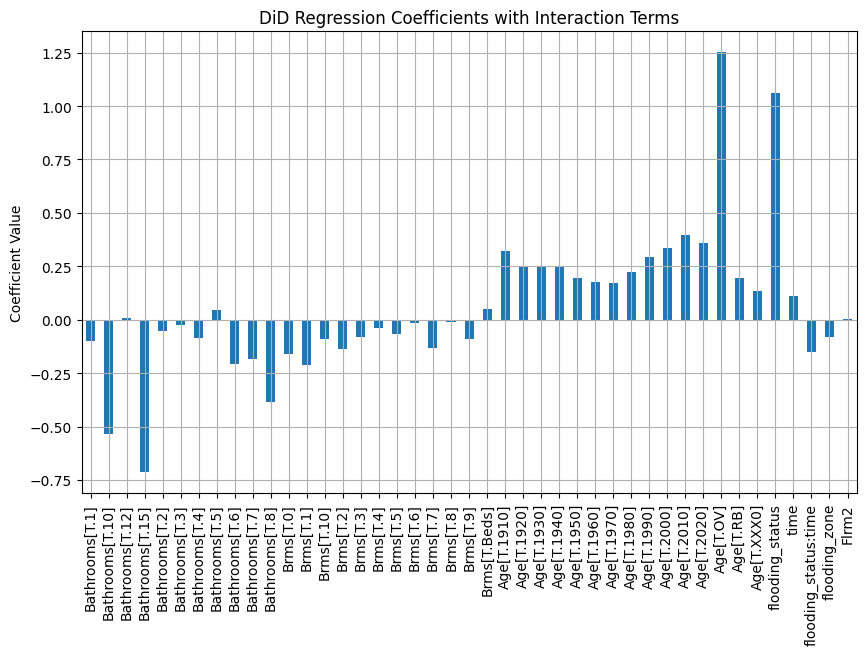

In [14]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 假设数据已经加载并进行预处理
file_path = '/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv'
data = pd.read_csv(file_path)

# 确保 'Total$' 是数值型并处理非数值字符
data['Total$'] = pd.to_numeric(data['Total$'].replace('[\$,]', '', regex=True), errors='coerce')
data['Ln_Total'] = np.log(data['Total$'])  # 计算对数

# 删除缺失值
data_clean = data.dropna(subset=['Ln_Total', 'Flrm2', 'Bathrooms', 'Brms', 'Age'])

# 处理时间列并过滤过去十年的数据
data_clean['Sale.Date'] = pd.to_datetime(data_clean['Sale.Date'], dayfirst=True, errors='coerce')
data_clean = data_clean.dropna(subset=['Sale.Date'])
data_clean['year'] = data_clean['Sale.Date'].dt.year

# 过滤出最近10年的数据
data_last_10_years = data_clean[data_clean['year'] >= (data_clean['year'].max() - 10)]

# 创建时间变量（时间趋势的代理），例如使用年份表示
data_last_10_years['time'] = data_last_10_years['year'] - data_last_10_years['year'].min()

# 1. 基础的差分中的差分模型
did_formula = 'Ln_Total ~ flooding_status + flooding_zone + Flrm2 + Bathrooms + Brms + Age + time'

# 2. 添加洪水状态与时间的交互项，来衡量随时间变化的洪水影响
did_formula_with_interaction = 'Ln_Total ~ flooding_status * time + flooding_zone + Flrm2 + Bathrooms + Brms + Age + time'

# 3. 使用 OLS 回归模型进行估计
did_model_with_interaction = smf.ols(formula=did_formula_with_interaction, data=data_last_10_years).fit()

# 打印模型结果
print(did_model_with_interaction.summary())

# 可视化模型的回归系数
coefs_with_interaction = did_model_with_interaction.params.drop('Intercept')
coefs_with_interaction.plot(kind='bar', figsize=(10, 6))
plt.title('DiD Regression Coefficients with Interaction Terms')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()


/tmp/ipykernel_17/438633486.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['Sale.Date'] = pd.to_datetime(data_clean['Sale.Date'], dayfirst=True, errors='coerce')


                            OLS Regression Results                            
Dep. Variable:               Ln_Total   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     2492.
Date:                Mon, 16 Sep 2024   Prob (F-statistic):               0.00
Time:                        09:09:18   Log-Likelihood:                -5485.1
No. Observations:               13375   AIC:                         1.098e+04
Df Residuals:                   13369   BIC:                         1.103e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          12.4254      0.014    8

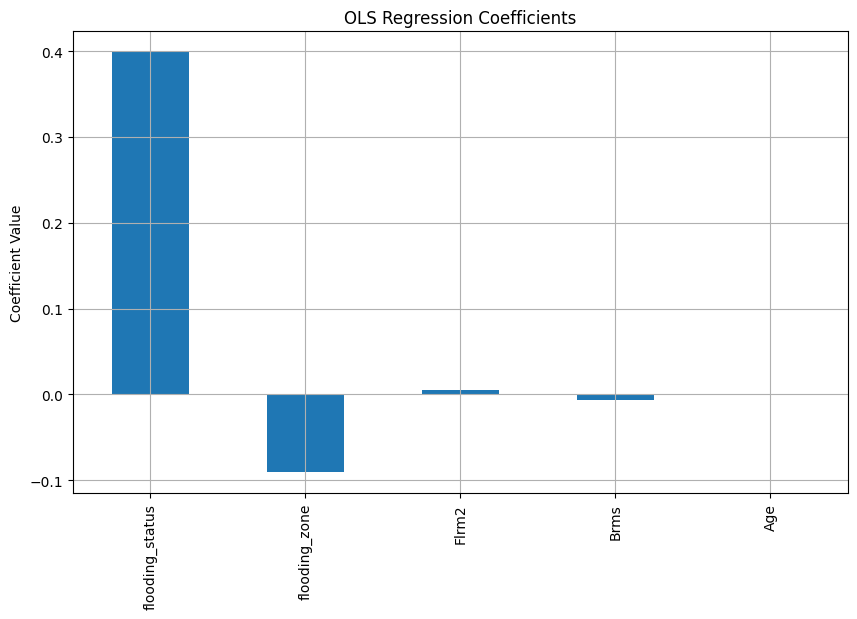

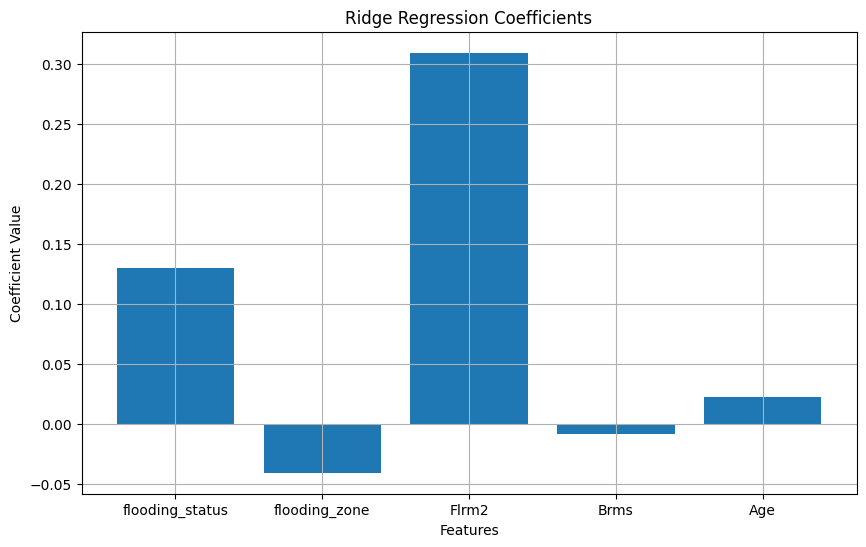

In [15]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 数据加载和预处理
# 确保 'Total$' 是数值型并处理非数值字符 file_path = '/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv'
data = pd.read_csv('/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv')
data['Total$'] = pd.to_numeric(data['Total$'].replace('[\$,]', '', regex=True), errors='coerce')

# 确保 Flrm2, Brms, Age 是数值型，并替换非数值字符为 NaN
data['Flrm2'] = pd.to_numeric(data['Flrm2'], errors='coerce')
data['Brms'] = pd.to_numeric(data['Brms'], errors='coerce')
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')

# 计算 'Ln_Total'
data['Ln_Total'] = np.log(data['Total$'])

# 删除缺失值
data_clean = data.dropna(subset=['Ln_Total', 'Flrm2', 'Brms', 'Age'])

# 2. 使用最近十年数据进行分析并处理日期格式
data_clean['Sale.Date'] = pd.to_datetime(data_clean['Sale.Date'], dayfirst=True, errors='coerce')
data_clean = data_clean.dropna(subset=['Sale.Date'])
data_last_10_years = data_clean[data_clean['Sale.Date'].dt.year >= (data_clean['Sale.Date'].dt.year.max() - 10)]

# 3. 保留Brms，定义DiD模型
did_formula = 'Ln_Total ~ flooding_status + flooding_zone + Flrm2 + Brms + Age'

# 4. 进行OLS回归
did_model = smf.ols(formula=did_formula, data=data_last_10_years).fit()

# 打印模型总结
print(did_model.summary())

# 5. 使用岭回归（Ridge Regression）来解决多重共线性
# 定义自变量和因变量
X = data_last_10_years[['flooding_status', 'flooding_zone', 'Flrm2', 'Brms', 'Age']]
y = data_last_10_years['Ln_Total']

# 确保自变量没有非数值数据
X = X.apply(pd.to_numeric, errors='coerce')

# 检查并处理缺失值
X = X.dropna()

# 将数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化数据
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 应用岭回归
ridge = Ridge(alpha=1.0)  # alpha 为正则化强度
ridge.fit(X_train_scaled, y_train)

# 打印岭回归系数
print("Ridge Regression Coefficients:", ridge.coef_)

# 打印岭回归模型得分（R²）
print("Ridge Regression Score on Test Set:", ridge.score(X_test_scaled, y_test))

# 6. 图表展示OLS模型的回归系数
coefs = did_model.params.drop('Intercept')
coefs.plot(kind='bar', figsize=(10, 6))
plt.title('OLS Regression Coefficients')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()

# 7. 可视化岭回归模型的回归系数
plt.figure(figsize=(10, 6))
plt.bar(X.columns, ridge.coef_)
plt.title('Ridge Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()


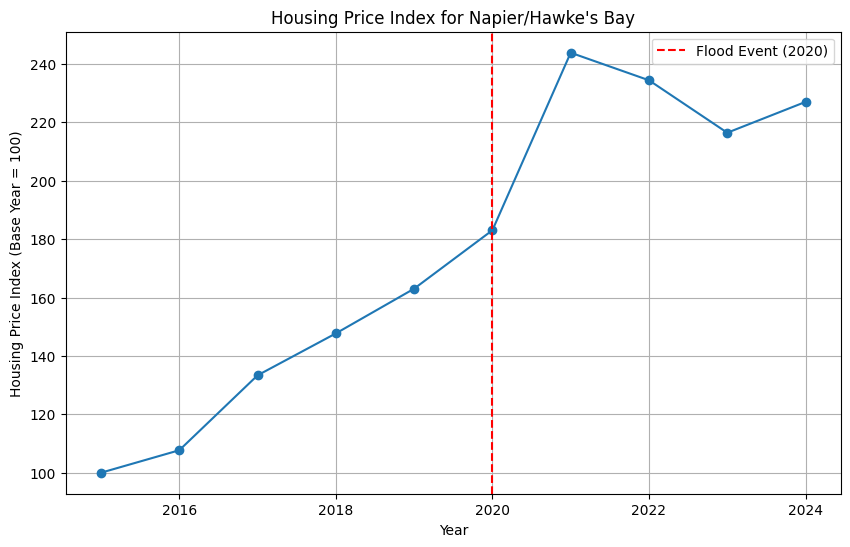

In [16]:
import pandas as pd

# Load the data
data = pd.read_csv('/kaggle/input/napier-data-cleaned/Napier_Data_cleaned_data.csv')

# Convert Sale.Date to datetime with dayfirst=True
data['Sale.Date'] = pd.to_datetime(data['Sale.Date'], dayfirst=True)

# Remove any non-numeric characters (like '$' or ',') from the Total$ column and convert to float
data['Total$'] = data['Total$'].replace('[\$,]', '', regex=True).astype(float)

# Extract year from the Sale.Date to create a time-based index
data['Year'] = data['Sale.Date'].dt.year

# Calculate the average price per year for the region
average_price_per_year = data.groupby('Year')['Total$'].mean()

# Normalize the prices to create an index, with the base year being the first year in the dataset
base_year = average_price_per_year.index.min()
price_index = (average_price_per_year / average_price_per_year.loc[base_year]) * 100

# Plot the Housing Price Index over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(price_index, marker='o', linestyle='-')
plt.axvline(x=2020, color='red', linestyle='--', label='Flood Event (2020)')
plt.title('Housing Price Index for Napier/Hawke\'s Bay')
plt.xlabel('Year')
plt.ylabel('Housing Price Index (Base Year = 100)')
plt.legend()
plt.grid(True)
plt.show()


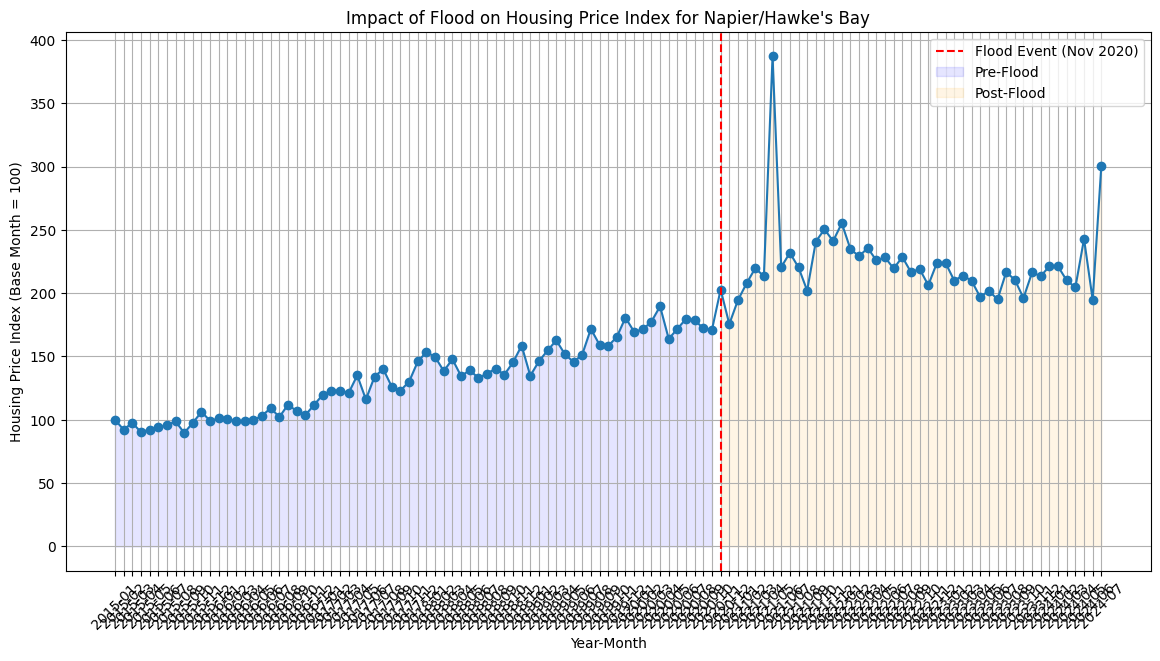

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/kaggle/input/napier-data/Napier_Data_new_0827.csv')

# Convert Sale.Date to datetime with dayfirst=True
data['Sale.Date'] = pd.to_datetime(data['Sale.Date'], dayfirst=True)

# Remove any non-numeric characters (like '$' or ',') from the Total$ column and convert to float
data['Total$'] = data['Total$'].replace('[\$,]', '', regex=True).astype(float)

# Extract year and month from the Sale.Date to create a time-based index
data['YearMonth'] = data['Sale.Date'].dt.to_period('M')

# Compute the average price per month for the region
average_price_per_month = data.groupby('YearMonth')['Total$'].mean().reset_index()

# Compute the Housing Price Index with the base month being the first month in the dataset
base_month_price = average_price_per_month['Total$'].iloc[0]
average_price_per_month['Price_Index'] = (average_price_per_month['Total$'] / base_month_price) * 100

# Identify the flood event month (assumed to be November 2020)
flood_month = '2020-11'

# Split the data into pre-flood and post-flood
pre_flood_data = average_price_per_month[average_price_per_month['YearMonth'] < flood_month]
post_flood_data = average_price_per_month[average_price_per_month['YearMonth'] >= flood_month]

# Plot the Housing Price Index over time
plt.figure(figsize=(14, 7))
plt.plot(average_price_per_month['YearMonth'].astype(str), average_price_per_month['Price_Index'], marker='o', linestyle='-')
plt.axvline(x=flood_month, color='red', linestyle='--', label='Flood Event (Nov 2020)')
plt.fill_between(pre_flood_data['YearMonth'].astype(str), pre_flood_data['Price_Index'], color='blue', alpha=0.1, label='Pre-Flood')
plt.fill_between(post_flood_data['YearMonth'].astype(str), post_flood_data['Price_Index'], color='orange', alpha=0.1, label='Post-Flood')
plt.title('Impact of Flood on Housing Price Index for Napier/Hawke\'s Bay')
plt.xlabel('Year-Month')
plt.ylabel('Housing Price Index (Base Month = 100)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


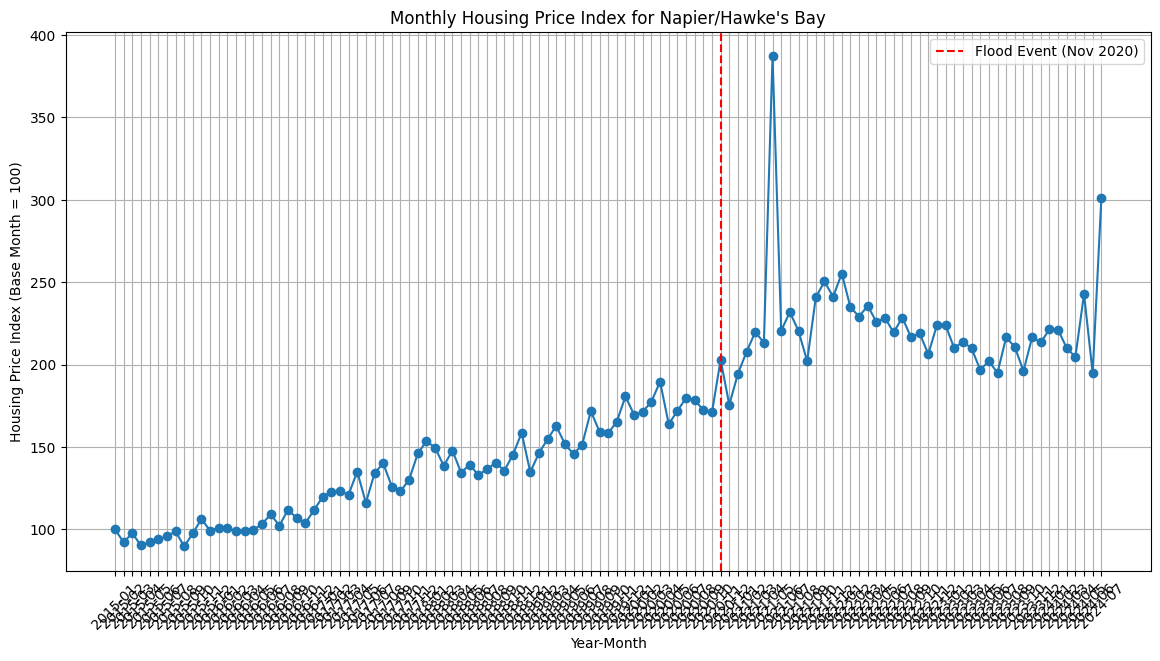

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/kaggle/input/napier-data/Napier_Data_new_0827.csv')

# Convert Sale.Date to datetime with dayfirst=True
data['Sale.Date'] = pd.to_datetime(data['Sale.Date'], dayfirst=True)

# Remove any non-numeric characters (like '$' or ',') from the Total$ column and convert to float
data['Total$'] = data['Total$'].replace('[\$,]', '', regex=True).astype(float)

# Extract year and month from the Sale.Date to create a time-based index
data['YearMonth'] = data['Sale.Date'].dt.to_period('M')

# Convert YearMonth to string for plotting
data['YearMonth'] = data['YearMonth'].astype(str)

# Calculate the average price per month for the region
average_price_per_month = data.groupby('YearMonth')['Total$'].mean()

# Normalize the prices to create an index, with the base month being the first month in the dataset
base_month = average_price_per_month.index.min()
price_index = (average_price_per_month / average_price_per_month.loc[base_month]) * 100

# Plot the Housing Price Index over time
plt.figure(figsize=(14, 7))
plt.plot(price_index, marker='o', linestyle='-')
plt.axvline(x='2020-11', color='red', linestyle='--', label='Flood Event (Nov 2020)')
plt.title('Monthly Housing Price Index for Napier/Hawke\'s Bay')
plt.xlabel('Year-Month')
plt.ylabel('Housing Price Index (Base Month = 100)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [19]:
import pandas as pd

# Load the data
data = pd.read_csv('/kaggle/input/napier-data/Napier_Data_new_0827.csv')

# Convert Sale.Date to datetime with dayfirst=True
data['Sale.Date'] = pd.to_datetime(data['Sale.Date'], dayfirst=True)

# Remove any non-numeric characters (like '$' or ',') from the Total$ column and convert to float
data['Total$'] = data['Total$'].replace('[\$,]', '', regex=True).astype(float)

# Extract year and month from the Sale.Date to create a time-based index
data['YearMonth'] = data['Sale.Date'].dt.to_period('M')

# Extract year from the Sale.Date to create a year-based index
data['Year'] = data['Sale.Date'].dt.year

# Group data by year and calculate the average price per year
average_price_per_year = data.groupby('Year')['Total$'].mean().reset_index()

# Generate and display a table for each year
for year in average_price_per_year['Year']:
    yearly_data = data[data['Year'] == year]
    
    # Check if YearMonth exists and generate the table accordingly
    if 'YearMonth' in yearly_data.columns:
        yearly_avg_price = yearly_data.groupby('YearMonth')['Total$'].mean().reset_index()
    else:
        yearly_avg_price = yearly_data.groupby('Year')['Total$'].mean().reset_index()

    print(f"\nYear: {year}")
    print(yearly_avg_price)



Year: 2015
   YearMonth         Total$
0    2015-01  366420.294118
1    2015-02  337824.115702
2    2015-03  357875.710938
3    2015-04  330708.215517
4    2015-05  338181.503497
5    2015-06  344455.624060
6    2015-07  350644.953020
7    2015-08  361835.413174
8    2015-09  328529.620112
9    2015-10  357630.739130
10   2015-11  389450.485030
11   2015-12  363174.271523

Year: 2016
   YearMonth         Total$
0    2016-01  370470.604651
1    2016-02  369031.962500
2    2016-03  362357.064039
3    2016-04  362658.843137
4    2016-05  365013.706186
5    2016-06  378486.208333
6    2016-07  400038.542857
7    2016-08  374432.142857
8    2016-09  410285.693431
9    2016-10  391533.546584
10   2016-11  379818.619718
11   2016-12  409204.546218

Year: 2017
   YearMonth         Total$
0    2017-01  438423.449153
1    2017-02  450544.537815
2    2017-03  450842.000000
3    2017-04  443679.256000
4    2017-05  494954.971098
5    2017-06  425189.260163
6    2017-07  491170.067227
7    2017-08

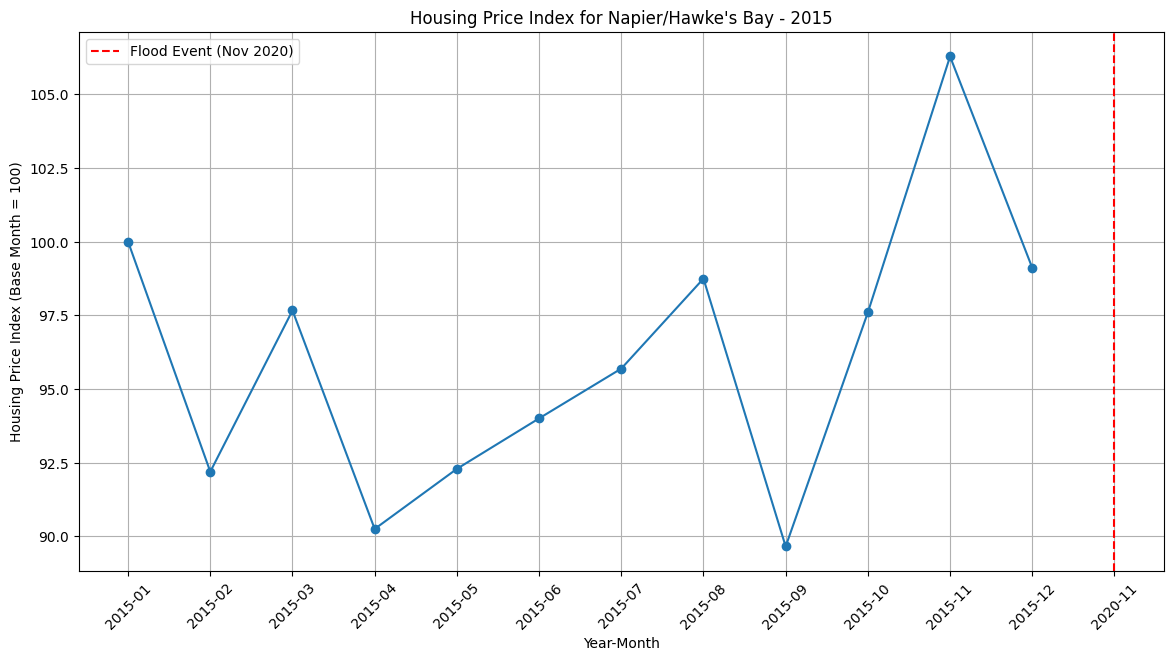

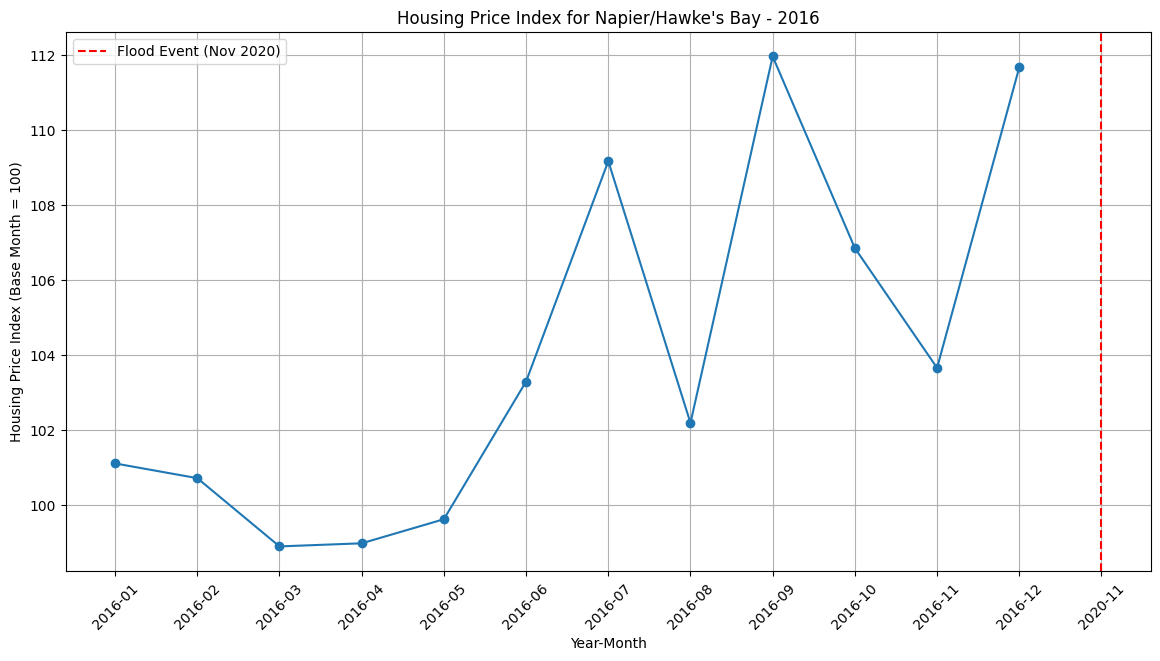

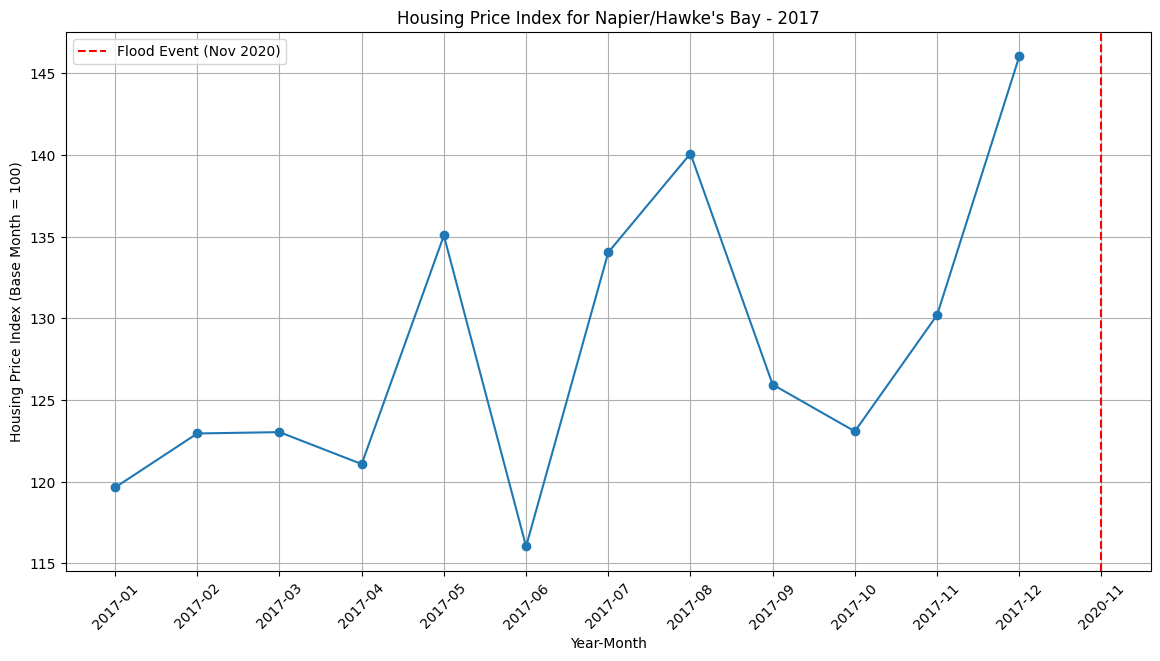

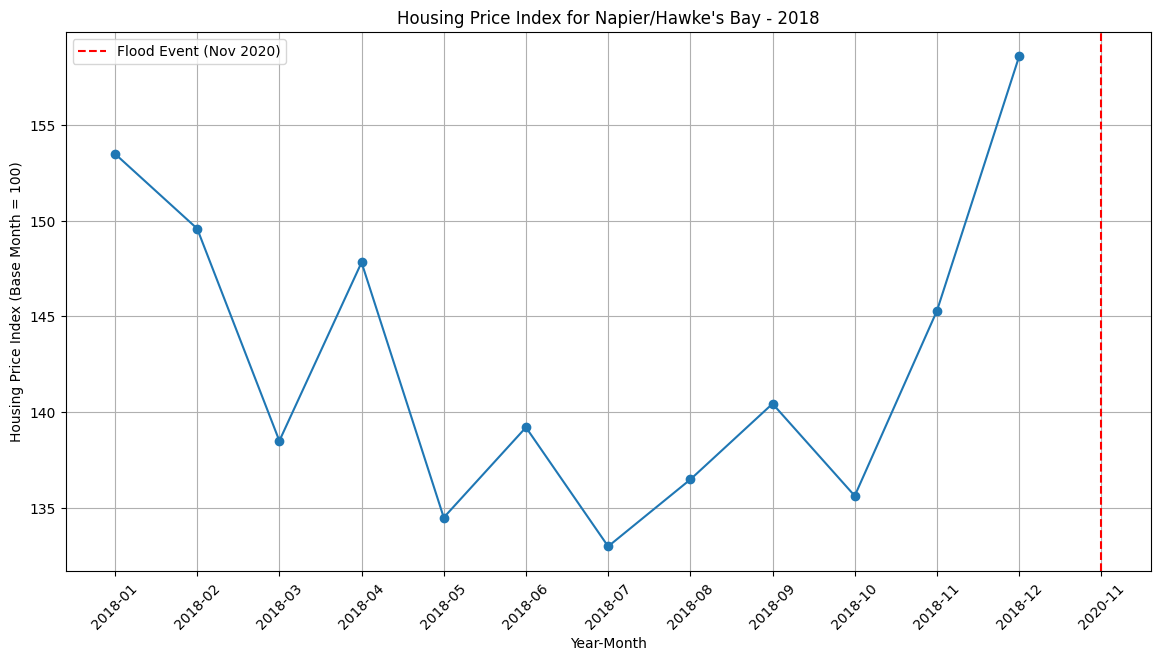

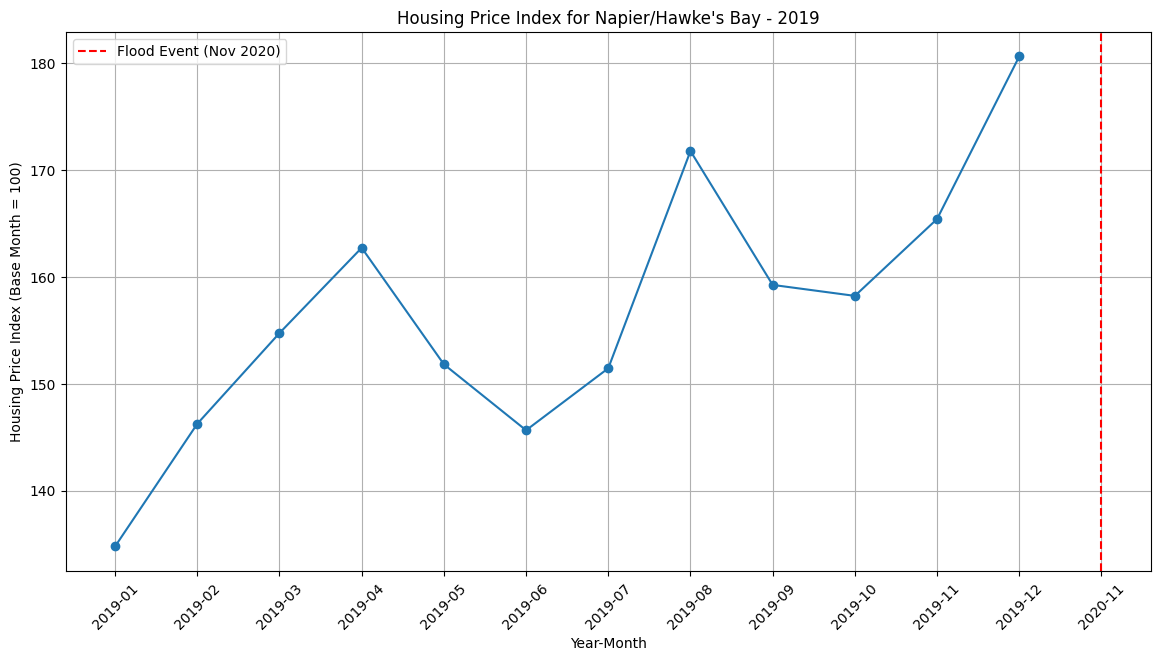

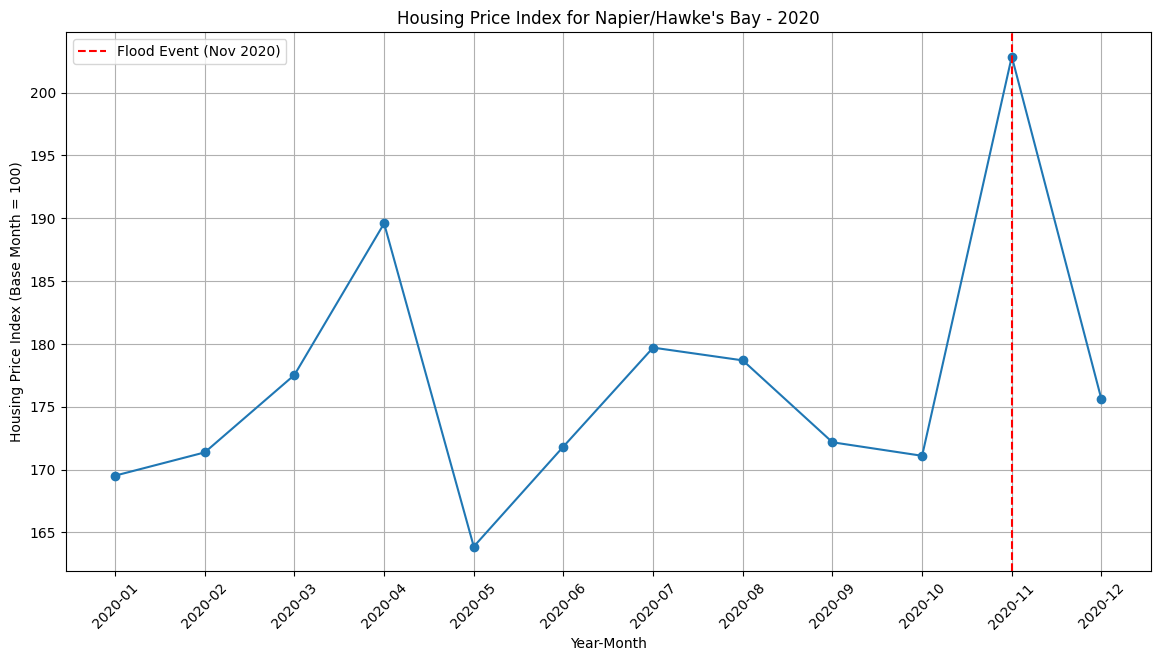

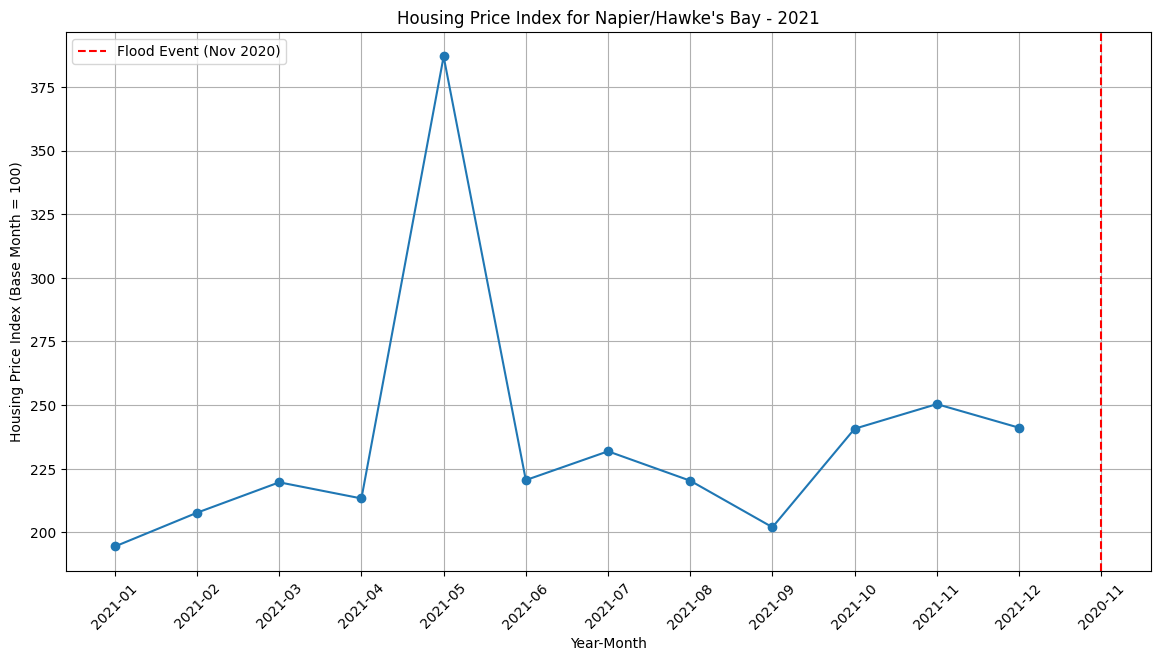

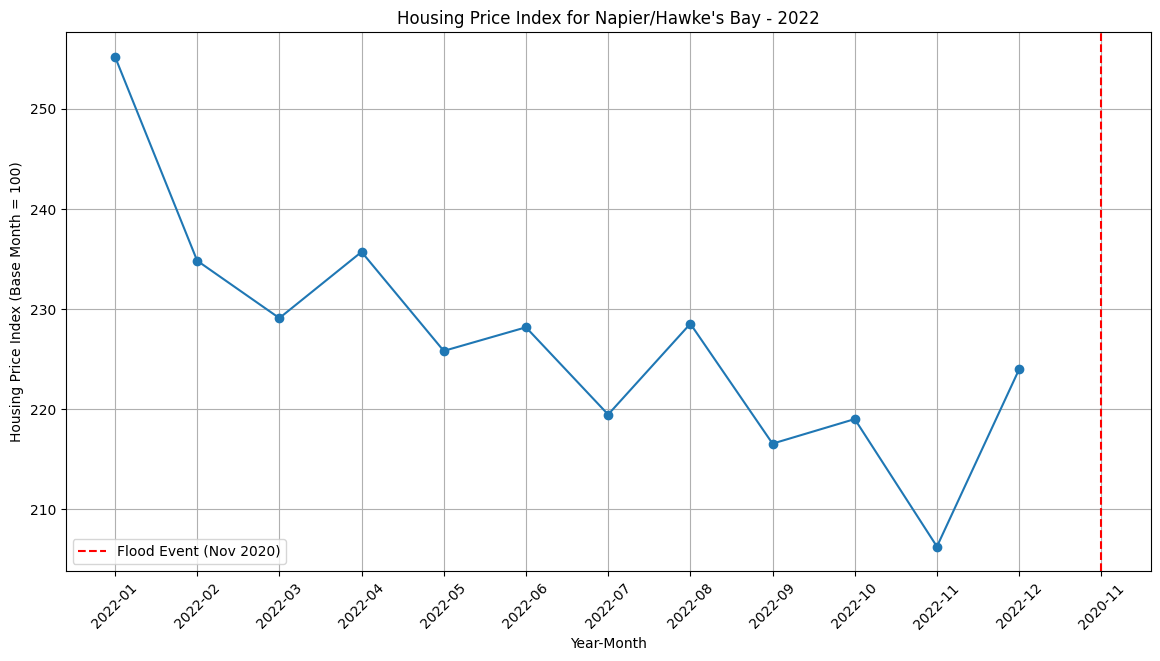

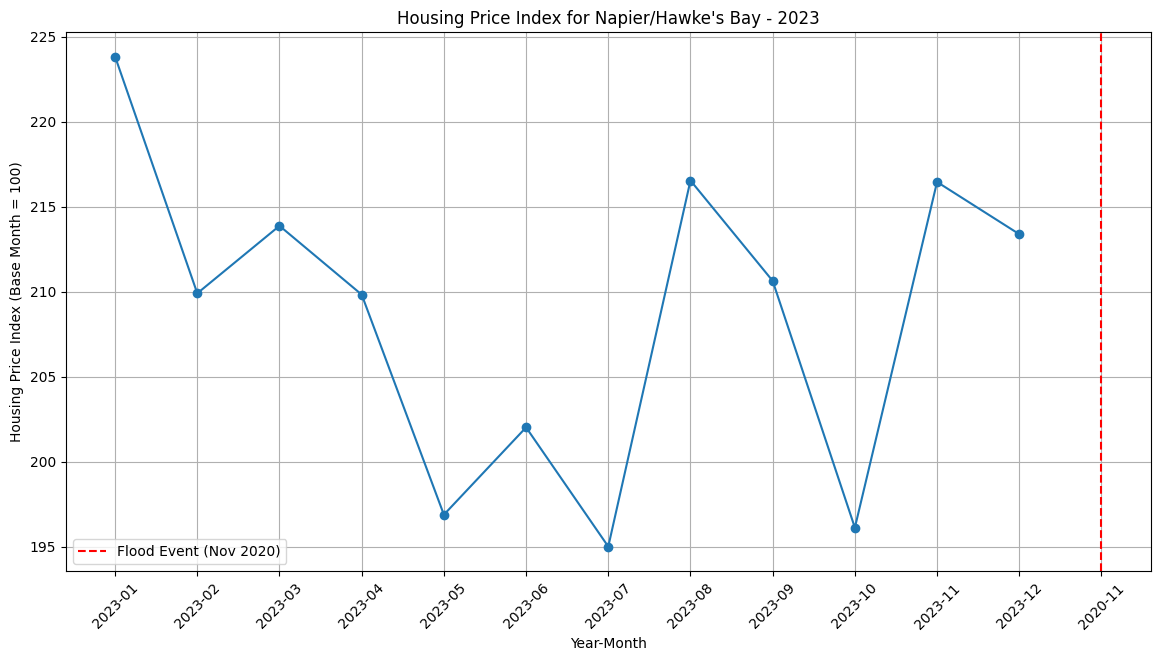

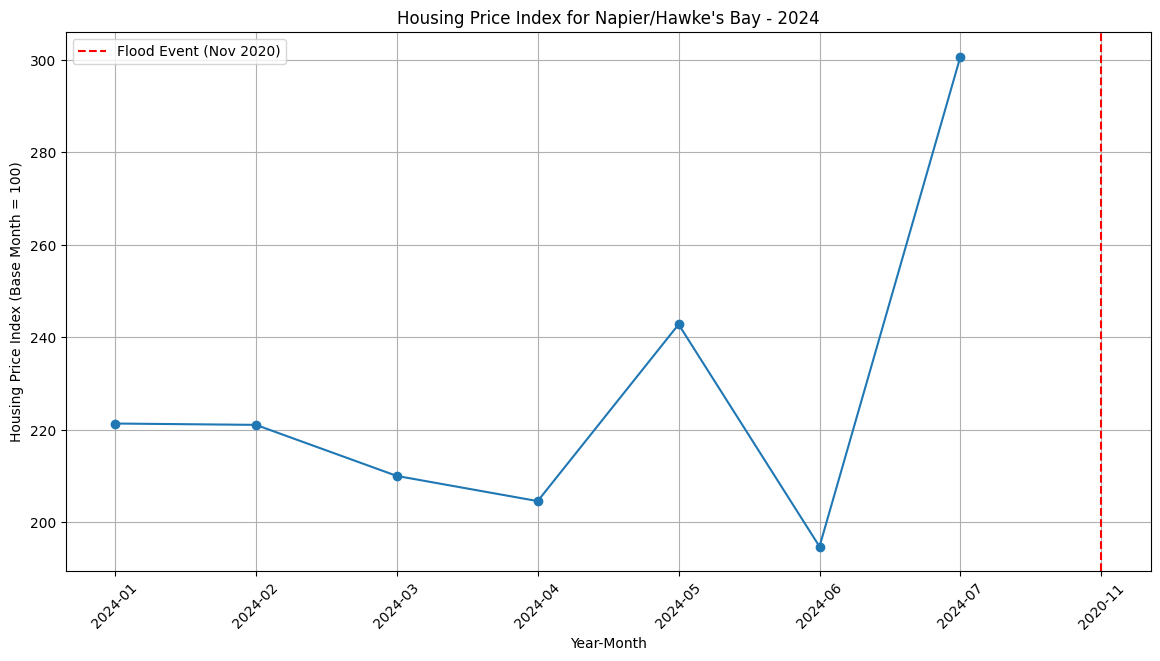

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/kaggle/input/napier-data/Napier_Data_new_0827.csv')

# Convert Sale.Date to datetime with dayfirst=True
data['Sale.Date'] = pd.to_datetime(data['Sale.Date'], dayfirst=True)

# Remove any non-numeric characters (like '$' or ',') from the Total$ column and convert to float
data['Total$'] = data['Total$'].replace('[\$,]', '', regex=True).astype(float)

# Extract year and month from the Sale.Date to create a time-based index
data['YearMonth'] = data['Sale.Date'].dt.to_period('M')

# Extract year for filtering
data['Year'] = data['Sale.Date'].dt.year

# Group data by YearMonth and Year to calculate the average price per month
average_price_per_month = data.groupby(['Year', 'YearMonth'])['Total$'].mean().reset_index()

# Normalize the prices to create an index, with the base month being the first month in the dataset
base_month = average_price_per_month['Total$'].iloc[0]
average_price_per_month['Price_Index'] = (average_price_per_month['Total$'] / base_month) * 100

# Plot the Housing Price Index for each year
years = average_price_per_month['Year'].unique()

for year in years:
    plt.figure(figsize=(14, 7))
    yearly_data = average_price_per_month[average_price_per_month['Year'] == year]
    plt.plot(yearly_data['YearMonth'].astype(str), yearly_data['Price_Index'], marker='o', linestyle='-')
    plt.axvline(x='2020-11', color='red', linestyle='--', label='Flood Event (Nov 2020)')
    plt.title(f'Housing Price Index for Napier/Hawke\'s Bay - {year}')
    plt.xlabel('Year-Month')
    plt.ylabel('Housing Price Index (Base Month = 100)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()


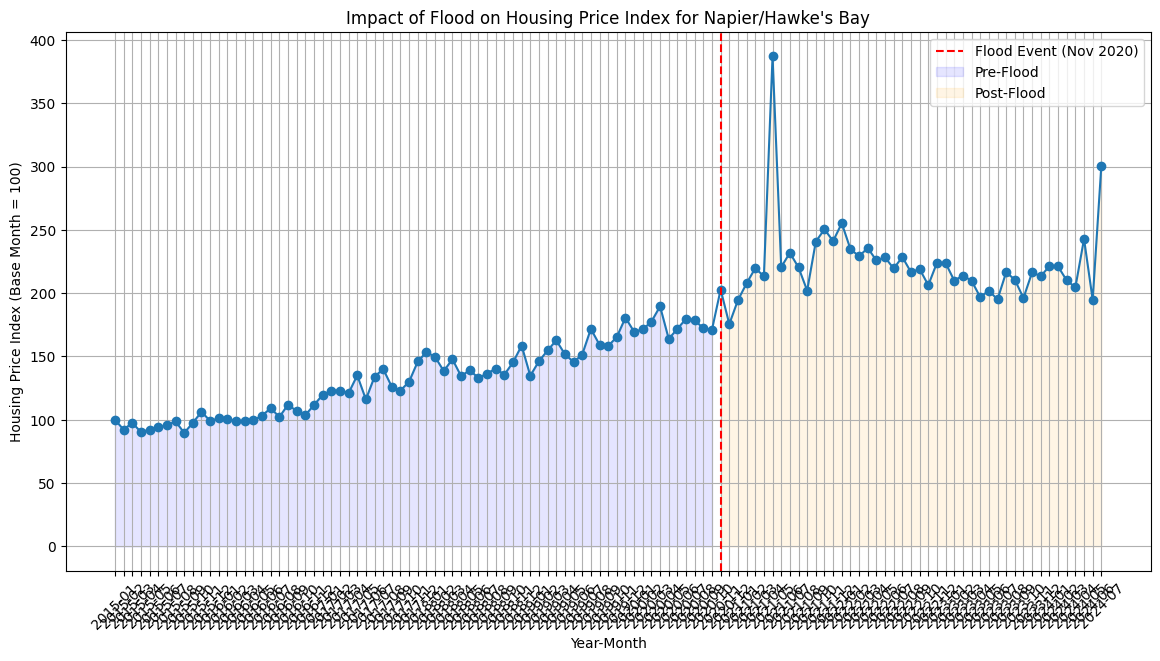

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/kaggle/input/napier-data/Napier_Data_new_0827.csv')

# Convert Sale.Date to datetime with dayfirst=True
data['Sale.Date'] = pd.to_datetime(data['Sale.Date'], dayfirst=True)

# Remove any non-numeric characters (like '$' or ',') from the Total$ column and convert to float
data['Total$'] = data['Total$'].replace('[\$,]', '', regex=True).astype(float)

# Extract year and month from the Sale.Date to create a time-based index
data['YearMonth'] = data['Sale.Date'].dt.to_period('M')

# Compute the average price per month for the region
average_price_per_month = data.groupby('YearMonth')['Total$'].mean().reset_index()

# Compute the Housing Price Index with the base month being the first month in the dataset
base_month_price = average_price_per_month['Total$'].iloc[0]
average_price_per_month['Price_Index'] = (average_price_per_month['Total$'] / base_month_price) * 100

# Identify the flood event month (assumed to be November 2020)
flood_month = '2020-11'

# Split the data into pre-flood and post-flood
pre_flood_data = average_price_per_month[average_price_per_month['YearMonth'] < flood_month]
post_flood_data = average_price_per_month[average_price_per_month['YearMonth'] >= flood_month]

# Plot the Housing Price Index over time
plt.figure(figsize=(14, 7))
plt.plot(average_price_per_month['YearMonth'].astype(str), average_price_per_month['Price_Index'], marker='o', linestyle='-')
plt.axvline(x=flood_month, color='red', linestyle='--', label='Flood Event (Nov 2020)')
plt.fill_between(pre_flood_data['YearMonth'].astype(str), pre_flood_data['Price_Index'], color='blue', alpha=0.1, label='Pre-Flood')
plt.fill_between(post_flood_data['YearMonth'].astype(str), post_flood_data['Price_Index'], color='orange', alpha=0.1, label='Post-Flood')
plt.title('Impact of Flood on Housing Price Index for Napier/Hawke\'s Bay')
plt.xlabel('Year-Month')
plt.ylabel('Housing Price Index (Base Month = 100)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


    Ln_Total  Flrm2 Brms   Age
0  13.304685    170    3  1990
1  14.603968    220    3  1990
2  13.134292     90    3  1950
3  12.886641     80    2  1970
4  13.795308    200    3  2000
                            OLS Regression Results                            
Dep. Variable:               Ln_Total   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     352.5
Date:                Mon, 16 Sep 2024   Prob (F-statistic):               0.00
Time:                        09:09:29   Log-Likelihood:                -5833.3
No. Observations:               13854   AIC:                         1.174e+04
Df Residuals:                   13816   BIC:                         1.203e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                      co

<Figure size 1000x600 with 0 Axes>

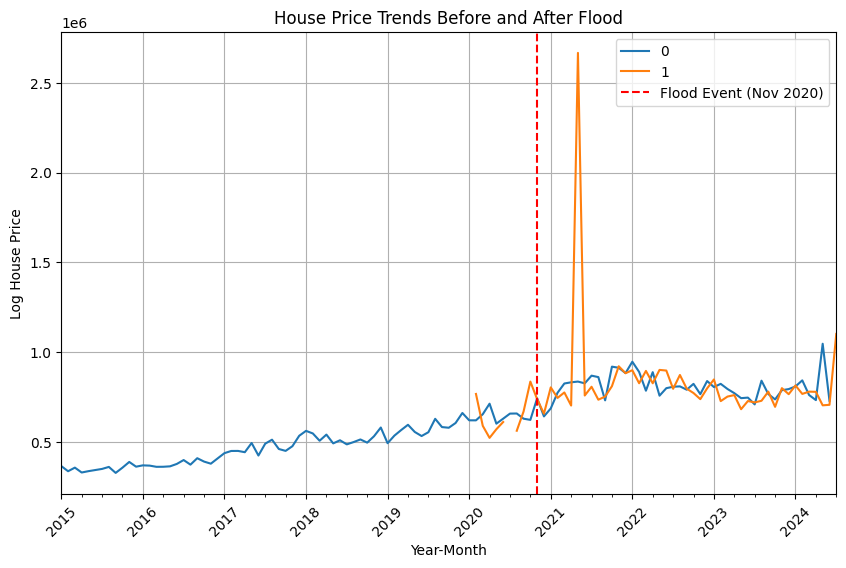

In [22]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load the dataset
file_path = '/kaggle/input/napier-data/Napier_Data_new_0827.csv'
data = pd.read_csv(file_path)

# Convert 'Total$' to numeric and handle non-numeric characters
data['Total$'] = pd.to_numeric(data['Total$'].replace('[\$,]', '', regex=True), errors='coerce')

# Create 'Ln_Total' by taking the logarithm of 'Total$'
data['Ln_Total'] = np.log(data['Total$'])

# Drop rows with missing values in the relevant columns
data_clean = data.dropna(subset=['Ln_Total', 'Flrm2', 'Brms', 'Age'])

# Verify the cleaned data
print(data_clean[['Ln_Total', 'Flrm2', 'Brms', 'Age']].head())

# Define the Difference-in-Differences (DiD) model formula
did_formula = 'Ln_Total ~ flooding_status + flooding_zone + Flrm2 + Brms + Age'

# Fit the DiD model using OLS regression
did_model = smf.ols(formula=did_formula, data=data_clean).fit()

# Display the model summary
print(did_model.summary())

# 绘制洪水前后房价变化的时间序列图
import matplotlib.pyplot as plt

# 将 'Sale.Date' 转换为日期格式，处理混合日期格式
data_clean['Sale.Date'] = pd.to_datetime(data_clean['Sale.Date'], dayfirst=True, errors='coerce')

# 检查并移除无效日期行
data_clean = data_clean.dropna(subset=['Sale.Date'])

# 提取年月用于时间序列分析
data_clean['YearMonth'] = data_clean['Sale.Date'].dt.to_period('M')

# 计算每月的平均房价（对数价格）
price_trends = data_clean.groupby(['YearMonth', 'flooding_status'])['Total$'].mean().unstack()

# 绘制洪水前后房价变化的时间序列图
plt.figure(figsize=(10, 6))
price_trends.plot(figsize=(10,6))
plt.axvline(x='2020-11', color='red', linestyle='--', label='Flood Event (Nov 2020)')
plt.title('House Price Trends Before and After Flood')
plt.ylabel('Log House Price')
plt.xlabel('Year-Month')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()